# Introduction to Natural Language Processing: Assignment 4

In this exercise we'll practice analysing the performance of our model on a classification task with imbalanced classes, and interpreting model attentions.

- You can use any Python package you need.
- Please comment your code
- This assignment is due Thursday at 23:59 **only** on eCampus: **Assignmnets >> Student Submissions >> Assignment 4 (Deadline: 18.12.2023, at 23:59)**

- Name the file aproppriately: "Assignment_4_\<Your_Name\>.ipynb" and submit only the Jupyter Notebook file.

# Task 1 (15 points)

In this task you'll analyse the performance of different approaches on a text classification task with imbalanced classes. We'll use a dataset of hotel reviews. The code provided to you below will load the dataset and model, and preprocess the data.

The original dataset has 5 classes, for 1 through 5 stars. We will define new labels, "1" for 1 star and "0" for all other values. This creates a class imbalance.

Hint: The training in this exercise will take fairly long (~20 minutes on Colab). For testing your solution, it is recommended to reduce the size of the dataset, then change to the full dataset once your code works.

In [1]:
!pip install datasets

In [19]:
import datasets
import torch
import numpy as np
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, EvalPrediction, Trainer, TrainingArguments
from typing import Dict
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pandas

In [3]:
model_source = "Snowflake/snowflake-arctic-embed-m" # recent encoder model, similar to BERT
tokenizer = AutoTokenizer.from_pretrained(model_source)
model = AutoModelForSequenceClassification.from_pretrained(model_source)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/738 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/436M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Snowflake/snowflake-arctic-embed-m and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [4]:
dataset = datasets.load_dataset("argilla/tripadvisor-hotel-reviews")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-0e99e58b23dccc(…):   0%|          | 0.00/19.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/20491 [00:00<?, ? examples/s]

In [5]:
# create train/val/test split
dataset = dataset['train'].train_test_split(test_size=0.2)
test_val = dataset['test'].train_test_split(test_size=0.5)
dataset['val'] = test_val['train']
dataset['test'] = test_val['test']

In [6]:
def process_batch(batch):
    # Tokenize the text
    tokenized = tokenizer(
        batch["text"],
        truncation=True,
        padding=True,
        max_length=512,
        return_tensors="pt"
    )

    # Process labels
    labels = []
    for predictions in batch["prediction"]:
        labels.append(1 if int(predictions[0]["label"]) == 1 else 0)

    return {**tokenized, "labels": labels}

dataset = dataset.map(process_batch, batched=True)

Map:   0%|          | 0/16392 [00:00<?, ? examples/s]

Map:   0%|          | 0/2050 [00:00<?, ? examples/s]

Map:   0%|          | 0/2049 [00:00<?, ? examples/s]

a) Implement the `my_metrics` function which takes as input an EvalPrediction. It should return the accuracy and at least one other metric appropriate for this task. Then, train the model for one epoch. Visualize the confusion matrix. Briefly discuss the performance of the model.

You can use an external library to help compute the metrics.

In [14]:
def my_metrics(eval_pred: EvalPrediction) -> Dict[str, float]:
    # YOUR CODE HERE
    logits, labels = eval_pred
    # Convert logits to class predictions (0 or 1)
    predictions = np.argmax(logits, axis=-1)

    # Calculate metrics
    acc = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='binary')

    return {
        "accuracy": acc,
        "f1_score": f1
    }
    pass


In [8]:
args = TrainingArguments(output_dir='.',
                         report_to="none",
                         num_train_epochs=1.0,
                         per_device_train_batch_size=32,
                         per_device_eval_batch_size=32,
                         )
collator = DataCollatorWithPadding(tokenizer=tokenizer)
trainer = Trainer(
    model=model,
    args=args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['val'],
    data_collator=collator,
    compute_metrics=my_metrics,
)

In [9]:
trainer.train()

Step,Training Loss
500,0.108300


TrainOutput(global_step=513, training_loss=0.10770847783451191, metrics={'train_runtime': 1612.7431, 'train_samples_per_second': 10.164, 'train_steps_per_second': 0.318, 'total_flos': 4312916419461120.0, 'train_loss': 0.10770847783451191, 'epoch': 1.0})

In [15]:
trainer.evaluate()

{'eval_loss': 0.08324402570724487,
 'eval_accuracy': 0.9643728648121035,
 'eval_f1_score': 0.7306273062730627,
 'eval_runtime': 69.3782,
 'eval_samples_per_second': 29.534,
 'eval_steps_per_second': 0.937,
 'epoch': 1.0}

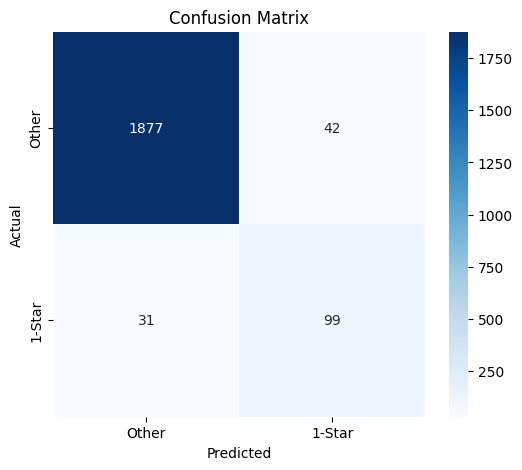

In [16]:
# YOUR CODE TO PLOT THE CONFUSION MATRIX
def plot_confusion_matrix(trainer, dataset):
    # Get predictions
    output = trainer.predict(dataset)
    preds = np.argmax(output.predictions, axis=-1)
    labels = output.label_ids

    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Other', '1-Star'],
                yticklabels=['Other', '1-Star'])
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
plot_confusion_matrix(trainer, dataset['val'])

In [ ]:
# DISCUSS THE RESULTS

The model achieves a high Accuracy of approximately **96.4%**. However, in the context of this imbalanced dataset where 1-star reviews are rare, accuracy is a misleading metric. A more reliable indicator of performance here is the F1-score, which is **0.73**.

Analysis of the Confusion Matrix


*   **True Negatives (1877)**: The model is very effective at identifying the majority class ("Other").
*   **True Positives (99)**: The model correctly identified 99 of the 1-star reviews.
*   **False Negatives (31)**: There are 31 instances where the model failed to detect a 1-star review, labeling it as "Other" instead.
*   **False Positives (42)**: The model incorrectly flagged 42 reviews as 1-star when they actually belonged to the "Other" category.

While the model performs well overall, the Precision and Recall for the minority class (1-star reviews) can be improved. The presence of 31 false negatives suggests that some negative sentiment is being missed, likely due to the significant class imbalance where the model leans toward predicting the majority "Other" label. The F1-score of 0.73 indicates a decent balance between precision and recall, but the model still struggles slightly with the scarcity of 1-star training examples.






b) Now, try two different approaches to improve the model's performance at dealing with class imbalance:

- Modify the loss function. (We didn't specify the loss function in the config, so first find out what the default loss function is.)
- Modify the dataset by removing majority class examples to get an even split

Compare the results.

In [17]:
# YOUR CODE HERE
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        # Calculate weights: Weight = Total_Samples / (Num_Classes * Samples_in_Class)
        # For simplicity, let's try a 1:5 ratio if Class 1 is rare
        weights = torch.tensor([1.0, 5.0]).to(model.device)
        loss_fct = nn.CrossEntropyLoss(weight=weights)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

# Re-initialize trainer with WeightedTrainer
weighted_trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['val'],
    data_collator=collator,
    compute_metrics=my_metrics,
)
weighted_trainer.train()

Step,Training Loss
500,0.121600


TrainOutput(global_step=513, training_loss=0.12305336667780291, metrics={'train_runtime': 1593.4332, 'train_samples_per_second': 10.287, 'train_steps_per_second': 0.322, 'total_flos': 4312916419461120.0, 'train_loss': 0.12305336667780291, 'epoch': 1.0})

In [20]:
# Separate the classes
train_df = dataset['train'].to_pandas()
class_0 = train_df[train_df['labels'] == 0]
class_1 = train_df[train_df['labels'] == 1]

# Undersample class 0 to match class 1 size
class_0_under = class_0.sample(len(class_1))
balanced_df = pandas.concat([class_0_under, class_1]).sample(frac=1) # shuffle

# Convert back to dataset
from datasets import Dataset
balanced_dataset = Dataset.from_pandas(balanced_df)

# Re-initialize a fresh model to avoid carrying over weights from previous training
model_undersampled = AutoModelForSequenceClassification.from_pretrained(model_source)

# Setup the Trainer with the balanced dataset
trainer_undersampled = Trainer(
    model=model_undersampled,
    args=args,
    train_dataset=balanced_dataset,
    eval_dataset=dataset['val'], # Still evaluate on the original imbalanced validation set
    data_collator=collator,
    compute_metrics=my_metrics,
)

# Train and evaluate
trainer_undersampled.train()
undersampled_results = trainer_undersampled.evaluate()
print("Undersampling Results:", undersampled_results)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at Snowflake/snowflake-arctic-embed-m and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Step,Training Loss


Undersampling Results: {'eval_loss': 0.1990097314119339, 'eval_accuracy': 0.9224011713030746, 'eval_f1_score': 0.6074074074074074, 'eval_runtime': 68.6036, 'eval_samples_per_second': 29.867, 'eval_steps_per_second': 0.947, 'epoch': 1.0}


c) For your best performing model, manually select 2 examples that are classified incorrectly. Can you give an intuitive explanation why the model classifies them wrong?

In [23]:
# YOUR ANSWER HERE
# Use the trainer that had the highest F1-score
best_trainer = trainer_undersampled

# Get predictions on the validation set
preds_output = best_trainer.predict(dataset['val'])
predictions = np.argmax(preds_output.predictions, axis=-1)
actuals = preds_output.label_ids

# Find two indices where the model was wrong
incorrect_idx = np.where(predictions != actuals)[0]

for i in incorrect_idx[:2]:
    idx = i.item()
    print(f"Example at Index {i}:")
    print(f"True Label: {actuals[i]} | Predicted: {predictions[i]}")
    print(f"Review: {dataset['val'][i]['text'][:300]}...") # Print first 300 chars
    print("-" * 50)

Example at Index 5:
True Label: 0 | Predicted: 1


TypeError: Wrong key type: '5' of type '<class 'numpy.int64'>'. Expected one of int, slice, range, str or Iterable.

# Task 2 (5 points)

In this task we'll take a quick dive into attention visualization. The implementation here is taken from https://github.com/mattneary/attention/blob/master/attention/attention.py with some minor changes.

In [ ]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

In [ ]:
model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct") # recent small GPT-like model
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2.5-0.5B-Instruct")

In [ ]:
def aggregate_attention(attn):
    '''Extract average attention vector'''
    avged = []
    for layer in attn:
        layer_attns = layer.squeeze(0)
        attns_per_head = layer_attns.mean(dim=0)
        vec = torch.concat((
            attns_per_head[-1],
            # add zero for the final generated token, which never
            # gets any attention
            torch.tensor([0.]),
        ))
        avged.append(vec / vec.sum())
    return torch.stack(avged).mean(dim=0)

def heterogenous_stack(vecs):
    '''Pad vectors with zeros then stack'''
    max_length = max(v.shape[0] for v in vecs)
    return torch.stack([
        torch.concat((v, torch.zeros(max_length - v.shape[0])))
        for v in vecs
    ])

In [ ]:
def get_completion(prompt):
    '''Get full text, token mapping, and attention matrix for a completion'''
    tokens = tokenizer.encode(prompt, return_tensors="pt")
    outputs = model.generate(
        tokens,
        max_new_tokens=3,
        output_attentions=True,
        return_dict_in_generate=True,
        early_stopping=True,
        length_penalty=-1,
        temperature=0.01,
    )
    sequences = outputs.sequences
    attn_m = heterogenous_stack([
        torch.tensor([
            1 if i == j else 0
            for j, token in enumerate(tokens[0])
        ])
        for i, token in enumerate(tokens[0])
    ] + list(map(aggregate_attention, outputs.attentions)))
    decoded = [tokenizer.decode(token) for token in sequences[0]]
    return decoded, attn_m

In [ ]:
decoded, attn_m = get_completion("John gave the book to Mary. The book was given to")

a) Interpret the results. What is the meaning of `attn_m`? Do you observe any interesting pattern?

b) Now try using an input consisting of random string of tokens with varying amounts of repetition. You should observe something like the following image (you do not need to make a nice plot). Intuitively, can you describe what is happening?

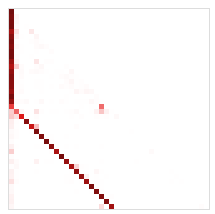

In [ ]:
random_token_string = # YOUR CODE HERE
decoded, attn_m = get_completion(random_token_string)
decoded, attn_m = get_completion(random_token_string + random_token_string[:2])
decoded, attn_m = get_completion(random_token_string * 2)